In [1]:
import sys
import os
import numpy as np
from sklearn.model_selection import train_test_split
sys.path.append(os.path.abspath('../src'))

from models.cnn_model import *
from utils.visualization import *

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

In [3]:
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
import numpy as np

import arviz as az
import matplotlib.pyplot as plt
import numpy as np

def extract_observations_from_shapefile(shp_file, tiff_file, X_data, depth_true):
    """
    Extrae coordenadas y profundidad real desde puntos en un shapefile.

    Parámetros:
    - shp_file: ruta al shapefile (.shp) con geometría y campo 'id'.
    - tiff_file: raster de referencia geoespacial.
    - X_data: array (1, H, W, 3) que contiene coordenadas x, y, etc.
    - depth_true: array (H, W) con valores de profundidad.

    Retorna:
    - x_coords_out: array con coordenadas X extraídas desde X_data.
    - y_coords_out: array con coordenadas Y extraídas desde X_data.
    - depth_values: array con valores de profundidad desde depth_true.
    """
    gdf = gpd.read_file(shp_file)
    shp_x_coords, shp_y_coords = gdf.geometry.x, gdf.geometry.y

    with rasterio.open(tiff_file) as src:
        rows_cols = [rowcol(src.transform, x, y) for x, y in zip(shp_x_coords, shp_y_coords)]

    x_coords_out = []
    y_coords_out = []
    depth_values = []

    pixel_x = []
    pixel_y = []

    for row, col in rows_cols:
        try:
            x = X_data[row, col, 1]#X_data[0, row, col, 1]
            y = X_data[row, col, 2]#X_data[0, row, col, 2]
            d_true = depth_true[row, col]

            x_coords_out.append(x)
            y_coords_out.append(y)
            pixel_x.append(row)
            pixel_y.append(col)
            depth_values.append(d_true)
        except IndexError:
            continue

    return np.array(pixel_x), np.array(pixel_y), np.array(x_coords_out), np.array(y_coords_out), np.array(depth_values)

In [4]:
correlation_map_train = np.load("../data/calibration/correlation_map_train.npy")
X_train = np.load("../data/x_cov.npy")

In [5]:
from flax.training import checkpoints
import os

# =======================
# Inicializar modelo base
# =======================
rng = jax.random.PRNGKey(0)
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)

model = CNNModel(use_correlation=False)
params = model.init(rng, X_train[:1], get_correlation_map_batch(correlation_map_train, 1))
state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

# =======================
# Restaurar desde checkpoint
# =======================
ckpt_dir = os.path.abspath("D:/Proyectos_GitHub/BayesHydroCNN/notebooks/checkpoints_nn")
state = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=state)

print("✅ Estado restaurado desde el checkpoint más reciente.")

✅ Estado restaurado desde el checkpoint más reciente.


In [6]:
sigma = 0.1 
ruido = np.random.normal(loc=0, scale=sigma, size=(387, 450, 1))
# 🔹 **Cargar datos asegurando `float64`**
x_cov = np.load("../data/calibration/x_cov.npy")#X_train[0,:,:,:]
true_image = np.load("../data/calibration/y_true.npy") + ruido
correlation_map = jnp.array(np.load("../data/calibration/correlation_map_train.npy"))
# ✅ **Asegurar que `true_image` tiene la forma correcta**
true_image = np.squeeze(true_image)  # Elimina dimensiones de tamaño 1 si exist
pixel_x, pixel_y, coords_x, coords_y, observed_values = extract_observations_from_shapefile(
    shp_file="D:/depths/TIF/CORRELATION/puntos_calibracion.shp",
    tiff_file="D:/depths/TIF/DEPTHS/depth_0.010_0.055.tiff",
    X_data=x_cov,
    depth_true=true_image
)

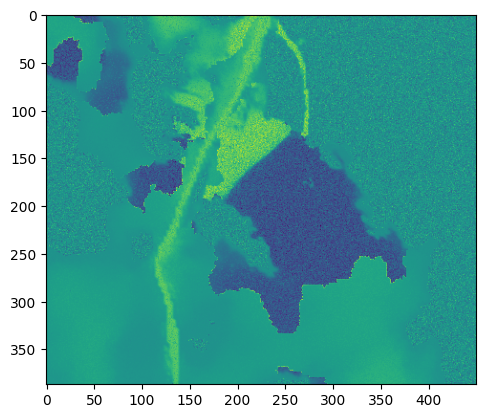

In [7]:
imagen = cnn_predict(x_cov,state, 0.02, 0.04,correlation_map)
plt.imshow(imagen)
plt.show()

La función observada se modela como:

$$
z(x) = S(x, \theta) + \delta(x) + \varepsilon(x)
$$

con:

$$
\delta(x) \sim \mathcal{GP}\left(\beta_1 x + \beta_2 y,\; \sigma_\delta^2 \exp\left[-\omega_x (x_i - x_i')^2 - \omega_y (y_i - y_i')^2\right]\right)
$$

$$
\varepsilon(x) \sim \mathcal{N}(0,\; \sigma^2 I)
$$


In [10]:
model1 = build_model(x_cov, state, correlation_map, true_image, coords_y, coords_x, pixel_x, pixel_y, observed_values, use_discrepancy=False)
with model1:
    step = pm.Slice()
    trace1 = pm.sample(
        draws=100,
        tune=20,
        chains=4,
        cores=10,
        step=step,
        idata_kwargs={"log_likelihood": False}
    )


Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Slice: [n1]
INFO:pymc.sampling.mcmc:>Slice: [n1]
>Slice: [n2]
INFO:pymc.sampling.mcmc:>Slice: [n2]
>Slice: [sigma]
INFO:pymc.sampling.mcmc:>Slice: [sigma]


Output()

Sampling 4 chains for 20 tune and 100 draw iterations (80 + 400 draws total) took 317 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 20 tune and 100 draw iterations (80 + 400 draws total) took 317 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [12]:
# Obtener resumen estadístico del trazado
summary = az.summary(trace1)

# Mostrar el resumen
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
n1,0.036,0.019,0.010,0.070,0.001,0.001,353.0,288.0,1.03
n2,0.043,0.022,0.011,0.079,0.001,0.001,528.0,323.0,1.03
sigma,4.035,0.371,3.430,4.795,0.015,0.018,580.0,333.0,1.01


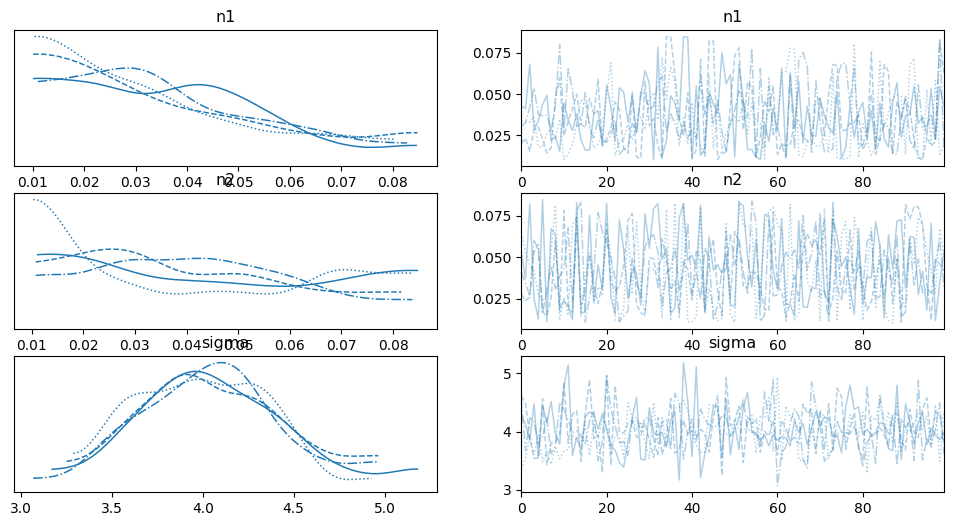

In [13]:
az.plot_trace(trace1)
plt.show()